# Phase 1 — Grafo Heterogêneo Música–Artista–Gênero (BR, 2017–2021)

Projeto: **BraSNAM 2026** — GNN temporal heterogêneo para difusão de popularidade musical (Oliveira et al. 2025).

**Esta apresentação cobre:**

1. Esquema do grafo (tipos de nós, relações)
2. Contagens de nós/arestas e dimensões de features
3. Checklist de validação C1–C9 da fase
4. Distribuições de grau (log-log) — evidência de hubs
5. Componentes conexos, *clustering* e comunidades de gênero (Louvain)
6. **Caso concreto:** vizinhança 1-hop de uma música do subset viral∩hit
7. *Smoke test* — forward pass de uma HeteroSAGE (2 camadas, hidden=128)
8. Próximos passos (Phase 2)

Plano e decisões: [`PLANO.md`](../PLANO.md) §2. Artefatos produzidos: `data/processed/graph/hetero_full.pt`, `node_id_map.json`, `results/phase1/`.

In [1]:
# Setup — imports, paths, carregar grafo persistido
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
%matplotlib inline

GRAPH_DIR = ROOT / "data" / "processed" / "graph"
g = torch.load(GRAPH_DIR / "hetero_full.pt", weights_only=False)
node_id_map = json.loads((GRAPH_DIR / "node_id_map.json").read_text())

print(f"Grafo carregado: {len(g.node_types)} tipos de nós, {len(g.edge_types)} relações.")
print(f"node_id_map: {list(node_id_map.keys())}")

/home/cristianomendieta/estudos/mestrado/mestrado-roadmap/music-influence-gnn/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Grafo carregado: 3 tipos de nós, 5 relações.
node_id_map: ['music', 'artist', 'genre']


## 1. Esquema do grafo

**Nós (3 tipos):**

- `music` — músicas do universo top200 ∪ viral50 (com features acústicas + metadados).
- `artist` — artistas brasileiros (catálogo `br-artists-all_time.csv`).
- `genre` — gêneros musicais agregados.

**Relações (5 tipos):**

| Aresta | Semântica |
|--------|-----------|
| `artist → performs → music` | Artista executa/é creditado na música |
| `artist → has_genre → genre` | Artista filiado ao gênero |
| `genre → rev_has_genre → artist` | Inverso (`ToUndirected` manual) |
| `music → cotrajectory → music` | Co-presença simultânea no Top200 (mesma semana) |
| `genre → cooccurs → genre` | Co-ocorrência de gêneros nos artistas |

Todas as arestas temporais carregam `first_seen_week ∈ [0, 260]` (≈ 5 anos × 52 semanas).

In [2]:
# Contagens e dimensões de features por tipo de nó
feat_desc = {
    "music": "9 acoustic z-score + popularity + explicit + song_type + streams + dias_no_chart + missing_flag",
    "artist": "metadados z-score (popularidade, followers, ...)",
    "genre": "embedding estrutural (TF-IDF/grau)",
}
df_nodes = pd.DataFrame([
    {
        "Tipo": nt,
        "Nós": g[nt].num_nodes,
        "Dim. x": tuple(g[nt].x.shape),
        "Features (resumo)": feat_desc.get(nt, "\u2014"),
    }
    for nt in g.node_types
])
df_nodes

,Tipo,Nós,Dim. x,Features (resumo)
0,music,6526,"(6526, 15)",9 acoustic z-score + popularity + explicit + s...
1,artist,1701,"(1701, 4)","metadados z-score (popularidade, followers, ...)"
2,genre,530,"(530, 32)",embedding estrutural (TF-IDF/grau)


In [3]:
# Contagens e atributos por tipo de aresta
def _et_str(et):
    return f"{et[0]} → {et[1]} → {et[2]}"

rows = []
for et in g.edge_types:
    store = g[et]
    has_attr = hasattr(store, "edge_attr") and store.edge_attr is not None
    attr_cols = (
        f"edge_attr {tuple(store.edge_attr.shape)}" if has_attr
        else ("first_seen_week" if "first_seen_week" in store else "\u2014")
    )
    rows.append({
        "Aresta": _et_str(et),
        "# arestas": store.edge_index.shape[1],
        "Atributos": attr_cols,
    })
df_edges = pd.DataFrame(rows)
df_edges

,Aresta,# arestas,Atributos
0,artist → performs → music,9274,"edge_attr (9274, 3)"
1,artist → has_genre → genre,3344,first_seen_week
2,genre → rev_has_genre → artist,3344,first_seen_week
3,music → cotrajectory → music,664577,"edge_attr (664577, 4)"
4,genre → cooccurs → genre,9866,"edge_attr (9866, 4)"


## 2. Checklist C1–C9 (validação do build)

Critérios definidos no design da Phase 1 ([`scripts/run_phase1.py`](../scripts/run_phase1.py)):

- **C1–C3:** contagens de nós dentro da tolerância (`music≈6469±100`, `artist=1701±5`, `genre=530±10`).
- **C4:** subset viral∩hit ⊆ nós `music`.
- **C5:** todo artista do subset é alcançável via `performs`.
- **C6:** nenhuma aresta com índice fora do `node_id_map`.
- **C7:** `first_seen_week ∈ [0, 260]` em todas as arestas com atributo temporal.
- **C8:** forward pass de HeteroSAGE produz embeddings finitos no shape correto.
- **C9:** `mask_until(w)` é monotônico em `w` para `cotrajectory`.

In [4]:
# Roda os checks C1-C9 e monta DataFrame [Critério, Esperado, Obtido, Status]
from music_diffusion_gnn.data.subset import load_subset
from music_diffusion_gnn.graph.build import _validate
from music_diffusion_gnn.graph.temporal import mask_until
from torch_geometric.nn import HeteroConv, SAGEConv

counts = {nt: g[nt].num_nodes for nt in g.node_types}
n_music, n_artist, n_genre = counts["music"], counts["artist"], counts["genre"]

subset_ids = load_subset(ROOT / "data" / "processed" / "subset_ids.json")
music_id_map = {s: i for i, s in enumerate(g["music"].song_id)}
subset_in_graph = [s for s in subset_ids if s in music_id_map]
missing = len(subset_ids) - len(subset_in_graph)

perf_et = ("artist", "performs", "music")
perf_ei = g[perf_et].edge_index
music_with_edges = set(perf_ei[1].tolist())
subset_idxs = {music_id_map[s] for s in subset_in_graph}
isolated = subset_idxs - music_with_edges

try:
    _validate(
        g,
        music_id_map,
        {a: i for i, a in enumerate(g["artist"].artist_id)},
        {gn: i for i, gn in enumerate(g["genre"].genre_name)},
    )
    c6_ok, c6_detail = True, "validate() passou"
except AssertionError as exc:
    c6_ok, c6_detail = False, str(exc)[:80]

c7_ok, c7_detail = True, "todas em [0, 260]"
for et in g.edge_types:
    store = g[et]
    keys = set(store.keys())
    if "edge_attr" in keys and store.edge_attr is not None and store.edge_attr.shape[1] > 0:
        fsw = store.edge_attr[:, -1]
    elif "first_seen_week" in keys:
        fsw = store.first_seen_week.float()
    else:
        continue
    if not ((fsw >= 0).all() and (fsw <= 260).all()):
        c7_ok = False
        c7_detail = f"{et}: min={fsw.min().item():.0f}, max={fsw.max().item():.0f}"
        break

HIDDEN = 128
conv1 = HeteroConv({et: SAGEConv((-1, -1), HIDDEN) for et in g.edge_types}, aggr="sum")
conv2 = HeteroConv({et: SAGEConv((-1, -1), HIDDEN) for et in g.edge_types}, aggr="sum")
with torch.no_grad():
    h = conv1(g.x_dict, g.edge_index_dict)
    h = {k: v.relu() for k, v in h.items()}
    out_smoke = conv2(h, g.edge_index_dict)
c8_shape = tuple(out_smoke["music"].shape)
c8_ok = c8_shape[1] == HIDDEN and torch.isfinite(out_smoke["music"]).all().item()

cotraj_et = ("music", "cotrajectory", "music")
g260 = mask_until(g, 260); g130 = mask_until(g, 130)
e260 = g260[cotraj_et].edge_index.shape[1]
e130 = g130[cotraj_et].edge_index.shape[1]
c9_ok = e130 <= e260

checks = [
    ("C1", "n_music",       "6469 ± 100",            n_music,                       abs(n_music - 6469) <= 100),
    ("C2", "n_artist",      "1701 ± 5",              n_artist,                      abs(n_artist - 1701) <= 5),
    ("C3", "n_genre",       "530 ± 10",              n_genre,                       abs(n_genre - 530) <= 10),
    ("C4", "subset ⊆ music", "missing = 0",          f"missing={missing}/{len(subset_ids)}", missing == 0),
    ("C5", "subset alcançável via performs", "isolated = 0", f"isolated={len(isolated)}", len(isolated) == 0),
    ("C6", "nenhuma aresta dangling", "validate() OK", c6_detail,                  c6_ok),
    ("C7", "first_seen_week ∈ [0, 260]", "OK",       c7_detail,                     c7_ok),
    ("C8", "HeteroSAGE forward", f"music shape = (·, {HIDDEN})", f"shape={c8_shape}", c8_ok),
    ("C9", "mask_until monotônico", "e(130) ≤ e(260)", f"{e130} ≤ {e260}",           c9_ok),
]

df_checks = pd.DataFrame(checks, columns=["#", "Critério", "Esperado", "Obtido", "Status"])
df_checks["Status"] = df_checks["Status"].map({True: "✅", False: "❌"})
df_checks

,#,Critério,Esperado,Obtido,Status
0,C1,n_music,6469 ± 100,6526,✅
1,C2,n_artist,1701 ± 5,1701,✅
2,C3,n_genre,530 ± 10,530,✅
3,C4,subset ⊆ music,missing = 0,missing=0/1981,✅
4,C5,subset alcançável via performs,isolated = 0,isolated=0,✅
5,C6,nenhuma aresta dangling,validate() OK,validate() passou,✅
6,C7,"first_seen_week ∈ [0, 260]",OK,"todas em [0, 260]",✅
7,C8,HeteroSAGE forward,"music shape = (·, 128)","shape=(6526, 128)",✅
8,C9,mask_until monotônico,e(130) ≤ e(260),336737 ≤ 664577,✅


## 3. Distribuições de grau (log-log)

Padrão *heavy-tailed* / power-law em redes sociais e culturais indica **hubs**: alguns artistas/músicas concentram a maior parte das conexões. Esperamos isso especialmente em `cotrajectory` (alguns hits dominam o Top200 por semanas) e `cooccurs` (gêneros guarda-chuva tipo *pop*, *funk*).

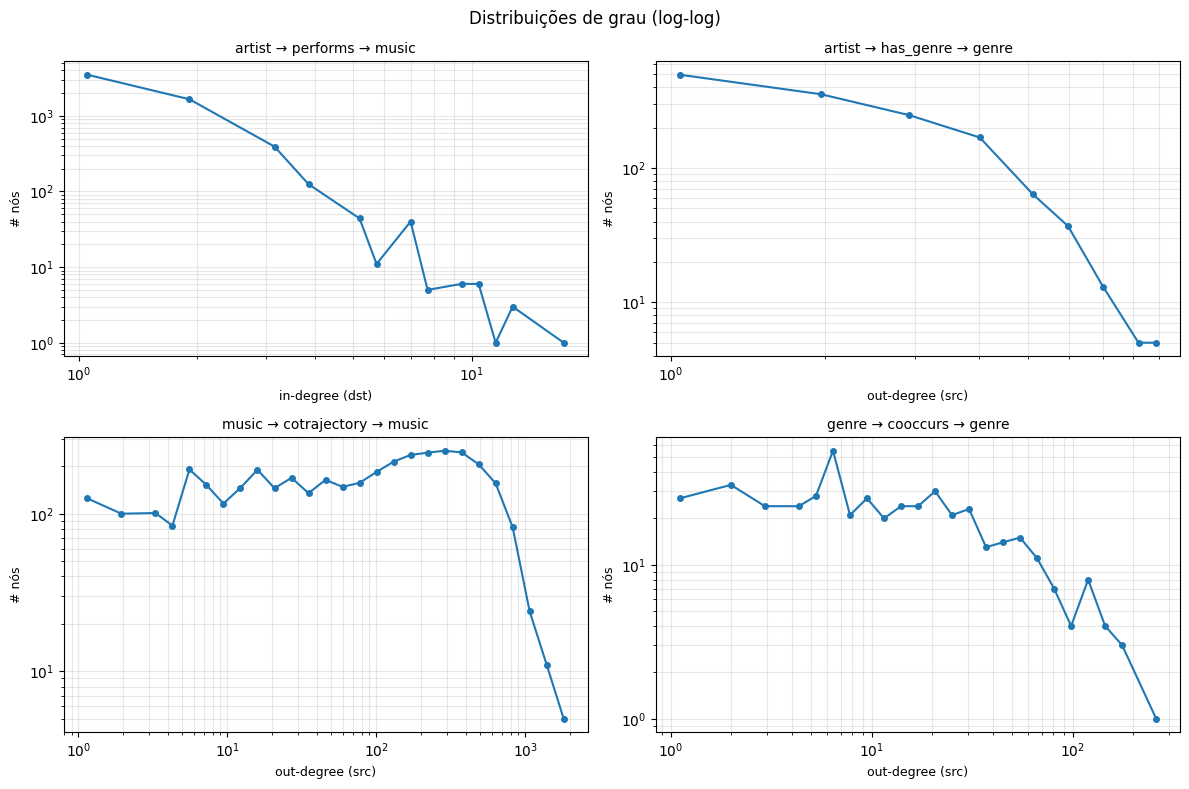

In [5]:
# Reimplementa o plot inline (a versão em stats.py usa backend Agg → arquivo)
edge_types_plot = [
    (("artist", "performs", "music"),       "artist → performs → music",     "dst"),
    (("artist", "has_genre", "genre"),      "artist → has_genre → genre",    "src"),
    (("music", "cotrajectory", "music"),    "music → cotrajectory → music",  "src"),
    (("genre", "cooccurs", "genre"),        "genre → cooccurs → genre",      "src"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (et, title, direction) in zip(axes.flatten(), edge_types_plot):
    ei = g[et].edge_index
    n_edges = ei.shape[1]
    src_type, _, dst_type = et
    n_src, n_dst = g[src_type].num_nodes, g[dst_type].num_nodes
    if direction == "src":
        deg = torch.zeros(n_src, dtype=torch.long)
        deg.scatter_add_(0, ei[0], torch.ones(n_edges, dtype=torch.long))
        xlabel = "out-degree (src)"
    else:
        deg = torch.zeros(n_dst, dtype=torch.long)
        deg.scatter_add_(0, ei[1], torch.ones(n_edges, dtype=torch.long))
        xlabel = "in-degree (dst)"
    deg_np = deg.numpy(); deg_np = deg_np[deg_np > 0]
    bins = np.logspace(np.log10(max(1, deg_np.min())), np.log10(deg_np.max() + 1), 30)
    counts_h, edges_h = np.histogram(deg_np, bins=bins)
    centers = 0.5 * (edges_h[:-1] + edges_h[1:])
    mask = counts_h > 0
    ax.loglog(centers[mask], counts_h[mask], "o-", markersize=4, lw=1.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9); ax.set_ylabel("# nós", fontsize=9)
    ax.grid(True, which="both", alpha=0.3)
fig.suptitle("Distribuições de grau (log-log)", fontsize=12)
fig.tight_layout()
plt.show()

## 4. Componentes conexos & clustering

Para cada relação calculamos:
- **Componentes conexos:** componentes isolados podem indicar músicas/artistas sem ponte temporal — relevante para *masking* da Phase 2.
- **Coeficiente de clustering médio:** apenas em relações homogêneas (`cotrajectory`, `cooccurs`); mede a *transitividade* da estrutura.

Usa-se [`compute_stats`](../src/music_diffusion_gnn/graph/stats.py) (cacheia também o Louvain usado na próxima célula).

In [6]:
from music_diffusion_gnn.graph.stats import compute_stats
stats = compute_stats(g)

df_components = pd.DataFrame(
    [{"Aresta": k, "# componentes": v} for k, v in stats["components"].items()]
)
df_clustering = pd.DataFrame(
    [{"Aresta": k, "Clustering médio": round(v, 4)} for k, v in stats["clustering"].items()]
)
print("Componentes conexos por relação:")
display(df_components)
print("\nCoeficiente de clustering (relações homogêneas):")
display(df_clustering)

Componentes conexos por relação:


,Aresta,# componentes
0,artist→performs→music,298
1,artist→has_genre→genre,360
2,genre→rev_has_genre→artist,51
3,music→cotrajectory→music,2379
4,genre→cooccurs→genre,70



Coeficiente de clustering (relações homogêneas):


,Aresta,Clustering médio
0,music→cotrajectory→music,0.5126
1,genre→cooccurs→genre,0.6040


## 5. Comunidades de gêneros (Louvain)

Rodamos Louvain (`networkx`, seed=42) sobre o subgrafo `genre → cooccurs → genre`. Cada comunidade tende a agrupar gêneros semanticamente próximos (ex.: derivados de *funk*, ramos do *sertanejo*, *pop* internacional).

In [7]:
louvain_rows = []
for rank, (size, names) in enumerate(stats["louvain_genre"], 1):
    sample = ", ".join(names[:8]) + ("…" if len(names) > 8 else "")
    louvain_rows.append({"Rank": rank, "Tamanho": size, "Amostra de gêneros": sample})
df_louvain = pd.DataFrame(louvain_rows)
df_louvain

,Rank,Tamanho,Amostra de gêneros
0,1,136,"adoracao, afrofuturismo brasileiro, agronejo, ..."
1,2,119,"afrobeats, afropop, alabama rap, album rock, a..."
2,3,96,"ai, alt z, alternative dance, alternative pop ..."
3,4,60,"australian pop, bboy, belgian dance, belgian e..."
4,5,43,"african rock, afro r&b, albanian hip hop, alba..."
5,6,7,"classic soul, motown, neo soul, northern soul,..."
6,7,1,adult standards
7,8,1,afrobeat brasileiro
8,9,1,australian rock
9,10,1,baroque pop


## 6. Caso concreto — vizinhança 1-hop de uma música

Para ilustrar a estrutura heterogênea, escolhemos **uma música do subset viral∩hit** que tenha pelo menos 2 vizinhos em `cotrajectory` e exibimos sua **vizinhança 1-hop**: artistas que a executam, gêneros desses artistas, e até 5 músicas co-trajetadas. Cores por tipo: música = azul, artista = laranja, gênero = verde.

In [8]:
from music_diffusion_gnn.data.loaders import load_songs

songs_df = load_songs()
id2name = dict(zip(songs_df["song_id"], songs_df["song_name"]))
id2artist_name = dict(zip(songs_df["song_id"], songs_df["artist_name"]))

# Índices auxiliares
music_ids = list(g["music"].song_id)
artist_ids = list(g["artist"].artist_id)
genre_names = list(g["genre"].genre_name)
music_id2idx = {s: i for i, s in enumerate(music_ids)}

perf_ei      = g[("artist", "performs", "music")].edge_index
has_genre_ei = g[("artist", "has_genre", "genre")].edge_index
cotraj_ei    = g[("music", "cotrajectory", "music")].edge_index

# Grau cotrajectory por música (não-direcionado lógico → soma src + dst)
cotraj_deg = torch.zeros(g["music"].num_nodes, dtype=torch.long)
cotraj_deg.scatter_add_(0, cotraj_ei[0], torch.ones(cotraj_ei.shape[1], dtype=torch.long))
cotraj_deg.scatter_add_(0, cotraj_ei[1], torch.ones(cotraj_ei.shape[1], dtype=torch.long))

# Escolhe 1ª música do subset com grau >= 2 e nome conhecido
chosen_id, chosen_idx = None, None
for sid in subset_in_graph:
    idx = music_id2idx[sid]
    if cotraj_deg[idx].item() >= 2 and sid in id2name:
        chosen_id, chosen_idx = sid, idx
        break

chosen_name = id2name.get(chosen_id, chosen_id)
chosen_artist = id2artist_name.get(chosen_id, "?")
print(f"Música central: '{chosen_name}' — {chosen_artist}  (song_id={chosen_id}, idx={chosen_idx})")
print(f"Grau cotrajectory: {cotraj_deg[chosen_idx].item()}")

Música central: 'Still Got Time (feat. PARTYNEXTDOOR)' — ['ZAYN', 'PARTYNEXTDOOR']  (song_id=000xQL6tZNLJzIrtIgxqSl, idx=1)
Grau cotrajectory: 305


Artistas (performs): 2
Gêneros (via artistas): 6
Músicas cotrajectory (até 5): 5


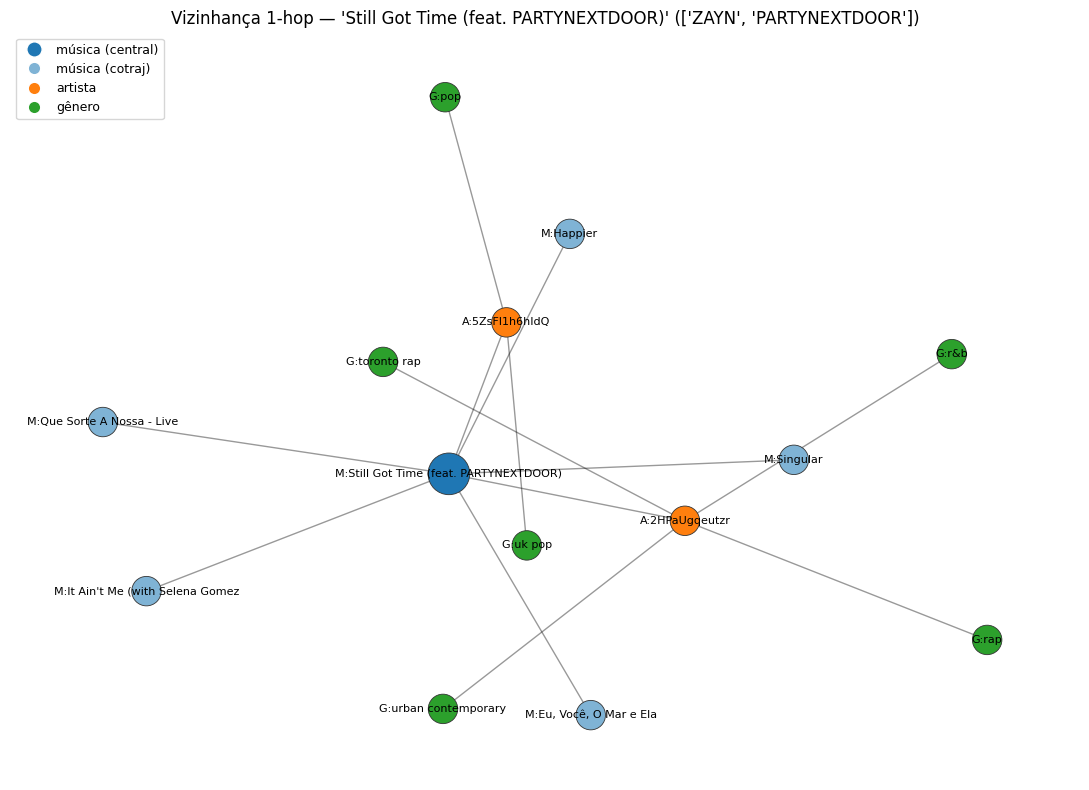

In [9]:
# stats.py importou matplotlib com backend Agg → restaurar inline antes do plot
%matplotlib inline

# Extrai vizinhança 1-hop
perf_mask = perf_ei[1] == chosen_idx
neighbor_artists = perf_ei[0][perf_mask].tolist()

neighbor_genres = set()
for a in neighbor_artists:
    g_mask = has_genre_ei[0] == a
    neighbor_genres.update(has_genre_ei[1][g_mask].tolist())
neighbor_genres = list(neighbor_genres)[:8]  # limita visual

co_src_mask = cotraj_ei[0] == chosen_idx
co_dst_mask = cotraj_ei[1] == chosen_idx
co_neighbors = set(cotraj_ei[1][co_src_mask].tolist()) | set(cotraj_ei[0][co_dst_mask].tolist())
co_neighbors.discard(chosen_idx)
co_neighbors = list(co_neighbors)[:5]

print(f"Artistas (performs): {len(neighbor_artists)}")
print(f"Gêneros (via artistas): {len(neighbor_genres)}")
print(f"Músicas cotrajectory (até 5): {len(co_neighbors)}")

# Constrói NetworkX
G = nx.Graph()
center_node = f"M:{chosen_name}"
G.add_node(center_node, ntype="music_center")

for a in neighbor_artists:
    label = f"A:{artist_ids[a][:12]}"
    G.add_node(label, ntype="artist")
    G.add_edge(center_node, label)
    for ge in neighbor_genres:
        g_label = f"G:{genre_names[ge]}"
        G.add_node(g_label, ntype="genre")
        if ((has_genre_ei[0] == a) & (has_genre_ei[1] == ge)).any().item():
            G.add_edge(label, g_label)

for m in co_neighbors:
    sid = music_ids[m]
    label = f"M:{id2name.get(sid, sid)[:30]}"
    G.add_node(label, ntype="music")
    G.add_edge(center_node, label)

color_map = {
    "music_center": "#1f77b4",
    "music":        "#7fb3d5",
    "artist":       "#ff7f0e",
    "genre":        "#2ca02c",
}
node_colors = [color_map[G.nodes[n]["ntype"]] for n in G.nodes]
node_sizes  = [900 if G.nodes[n]["ntype"] == "music_center" else 450 for n in G.nodes]

fig, ax = plt.subplots(figsize=(11, 8))
pos = nx.spring_layout(G, seed=42, k=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.4, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                       edgecolors="#333", linewidths=0.6, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
ax.set_title(f"Vizinhança 1-hop — '{chosen_name}' ({chosen_artist})", fontsize=12)
ax.axis("off")

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker="o", color="w", label="música (central)",
           markerfacecolor=color_map["music_center"], markersize=11),
    Line2D([0], [0], marker="o", color="w", label="música (cotraj)",
           markerfacecolor=color_map["music"], markersize=9),
    Line2D([0], [0], marker="o", color="w", label="artista",
           markerfacecolor=color_map["artist"], markersize=9),
    Line2D([0], [0], marker="o", color="w", label="gênero",
           markerfacecolor=color_map["genre"], markersize=9),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=9, frameon=True)
fig.tight_layout()
plt.show()


## 7. Smoke test — HeteroSAGE (2 camadas, hidden=128)

Confirmamos que o grafo é consumível por uma GNN heterogênea genérica. Empilhamos dois `HeteroConv(SAGEConv)` com agregação por soma e fazemos um forward sem treinar. O *output* esperado tem shape `(n_music, 128)` e valores finitos.

In [10]:
HIDDEN = 128
conv1 = HeteroConv({et: SAGEConv((-1, -1), HIDDEN) for et in g.edge_types}, aggr="sum")
conv2 = HeteroConv({et: SAGEConv((-1, -1), HIDDEN) for et in g.edge_types}, aggr="sum")

with torch.no_grad():
    h = conv1(g.x_dict, g.edge_index_dict)
    h = {k: v.relu() for k, v in h.items()}
    out = conv2(h, g.edge_index_dict)

print(f"music embedding shape : {tuple(out['music'].shape)}")
print(f"artist embedding shape: {tuple(out['artist'].shape)}")
print(f"genre embedding shape : {tuple(out['genre'].shape)}")
print(f"music.isfinite().all(): {bool(torch.isfinite(out['music']).all().item())}")

music embedding shape : (6526, 128)
artist embedding shape: (1701, 128)
genre embedding shape : (530, 128)
music.isfinite().all(): True


## 8. Próximos passos — Phase 2 (Temporal GNN)

O artefato `hetero_full.pt` é o **insumo direto** para a Phase 2:

1. **Masking temporal.** A função [`mask_until(g, week_t)`](../src/music_diffusion_gnn/graph/temporal.py#L32) retorna uma cópia do grafo restrita às arestas com `first_seen_week ≤ t`. C9 já valida monotonicidade.
2. **Janela deslizante.** Para cada semana `t ∈ [W, 260]`, gerar `g_t = mask_until(g, t)` e treinar um modelo temporal (HeteroGNN + GRU/atenção) prevendo *virality* e *success* de cada música.
3. **Baselines.** Comparar contra a SIR (Phase 0): RMSE virality 0.0289 / RMSE success 0.0471.
4. **Avaliação.** Métricas por janela temporal + análise por subset viral∩hit (1.981 músicas).

Plano detalhado: [`PLANO.md`](../PLANO.md).